# Clustering-Based Tracking Portfolio for S&P 500

Based on: [Reproducing the S&P 500 by Clustering](https://quantdare.com/reproducing-the-sp500-by-clustering/)

## Methodology Pipeline

1. **Weekly feature construction** — for each stock: 5 daily returns + 5 daily market-cap changes = 10D weekly feature vector
2. **t-SNE** — compress 10D weekly features → 2D embedding per stock (aggregated over the fit period)
3. **Affinity Propagation** — cluster stocks in 2D t-SNE space (automatically determines number of clusters, no k needed)
4. **Stock selection** — pick the stock nearest to each cluster centroid (one per cluster)
5. **Weight optimization** — long-only simplex weights fitted on fit+selection period
6. **Evaluation** — holdout tracking error, IR, sector drift

Additionally, we sweep over **K-Means with k = 10 to 100** to produce the required sparsity vs TE trade-off chart.

In [ ]:
!pip -q install cvxpy yfinance tqdm lxml html5lib beautifulsoup4 scikit-learn

In [ ]:
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

import cvxpy as cp
import yfinance as yf

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import AffinityPropagation, KMeans
from sklearn.metrics import pairwise_distances

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR        = Path('/content/drive/MyDrive/Mega')
CACHE_DIR       = Path('/content/drive/MyDrive/Mega/cache')
SECTOR_CACHE    = CACHE_DIR / 'sector_map.csv'
MARKETCAP_CACHE = CACHE_DIR / 'market_caps.csv'

FIT_START  = '2020-01-01'
FIT_END    = '2024-12-31'
SEL_START  = '2025-01-01'
SEL_END    = '2025-06-30'
HOLD_START = '2025-07-01'
HOLD_END   = '2025-12-31'

K_LIST = list(range(10, 101))  # for K-Means sweep
L2     = 1e-6

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print('Drive mount skipped:', e)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
print('Data dir exists:', DATA_DIR.exists())
print('Example files:', [p.name for p in list(DATA_DIR.rglob('*.csv'))[:5]])

Mounted at /content/drive
Data dir exists: True
Example files: ['sp500_tickers_cache.csv', 'ABNB.csv', 'APP.csv', 'CARR.csv', 'CEG.csv']


In [ ]:
def load_ticker_cache(data_dir: Path, cache_name: str = 'sp500_tickers_cache.csv') -> pd.Series:
    cache_path = next(data_dir.rglob(cache_name), None)
    if cache_path is None:
        raise FileNotFoundError(f'{cache_name} not found under {data_dir}.')
    cache_df  = pd.read_csv(cache_path)
    cache_col = cache_df.columns[0]
    tickers   = cache_df[cache_col].astype(str).str.strip()
    tickers   = tickers[tickers.ne('')].drop_duplicates().reset_index(drop=True)
    print(f'Tickers in cache: {len(tickers)}')
    return tickers


def load_price_panel(data_dir: Path, benchmark_stems=('^GSPC', 'GSPC'), cache_name='sp500_tickers_cache.csv'):
    if not data_dir.exists():
        raise FileNotFoundError(f'Data directory does not exist: {data_dir}')
    all_csvs       = sorted(data_dir.rglob('*.csv'))
    benchmark_path = next((p for p in all_csvs if p.stem in benchmark_stems), None)
    if benchmark_path is None:
        raise FileNotFoundError(f'Benchmark file not found under {data_dir}')

    bench_df  = pd.read_csv(benchmark_path, parse_dates=['Date'])
    bench_df  = bench_df.sort_values('Date').drop_duplicates('Date', keep='last')
    benchmark = bench_df.set_index('Date')['Close'].astype(float).rename('benchmark').sort_index()

    stock_series, loaded, skipped = [], [], []
    for fp in all_csvs:
        if fp.name in {cache_name, benchmark_path.name}:
            continue
        ticker = fp.stem
        try:
            df = pd.read_csv(fp, parse_dates=['Date'])
        except Exception:
            skipped.append(ticker); continue
        if 'Date' not in df.columns:
            skipped.append(ticker); continue
        df        = df.sort_values('Date').drop_duplicates('Date', keep='last')
        price_col = 'Adj Close' if 'Adj Close' in df.columns else ('Close' if 'Close' in df.columns else None)
        if price_col is None:
            skipped.append(ticker); continue
        s = df.set_index('Date')[price_col].astype(float).rename(ticker).sort_index()
        if s.notna().sum() < 50:
            skipped.append(ticker); continue
        stock_series.append(s)
        loaded.append(ticker)

    prices    = pd.concat(stock_series, axis=1).sort_index()
    common    = prices.index.intersection(benchmark.index)
    prices    = prices.loc[common].replace([np.inf, -np.inf], np.nan)
    benchmark = benchmark.loc[common]
    prices    = prices.loc[benchmark.notna()]
    benchmark = benchmark.loc[benchmark.notna()]
    print(f'Loaded: {len(loaded)} stocks | Price panel: {prices.shape}')
    return prices, benchmark


sp500_tickers     = load_ticker_cache(DATA_DIR)
prices, benchmark = load_price_panel(DATA_DIR)

Tickers in cache: 503
Loaded: 578 stocks | Price panel: (1525, 578)


In [ ]:
bench_ret    = benchmark.pct_change().rename('benchmark_ret')
stock_rets   = prices.pct_change()
aligned      = stock_rets.join(bench_ret, how='inner').dropna(subset=['benchmark_ret'])
stock_ret_df = aligned.drop(columns=['benchmark_ret'])
bench_ret    = aligned['benchmark_ret']

print('Return matrix:', stock_ret_df.shape)
print('Date range:', stock_ret_df.index.min().date(), '->', stock_ret_df.index.max().date())

Return matrix: (1524, 578)
Date range: 2020-01-03 -> 2026-01-27


In [ ]:
pre_holdout_mask = (stock_ret_df.index >= FIT_START) & (stock_ret_df.index <= SEL_END)
coverage         = stock_ret_df.loc[pre_holdout_mask].notna().mean().sort_values(ascending=False)
eligible_tickers = coverage[coverage >= 0.95].index.tolist()
print('Eligible tickers:', len(eligible_tickers))

X_all = stock_ret_df[eligible_tickers].copy()
y_all = bench_ret.loc[X_all.index].copy()

fit_mask  = (X_all.index >= FIT_START)  & (X_all.index <= FIT_END)
sel_mask  = (X_all.index >= SEL_START)  & (X_all.index <= SEL_END)
hold_mask = (X_all.index >= HOLD_START) & (X_all.index <= HOLD_END)

X_fit_raw  = X_all.loc[fit_mask];   y_fit  = y_all.loc[fit_mask]
X_sel_raw  = X_all.loc[sel_mask];   y_sel  = y_all.loc[sel_mask]
X_hold_raw = X_all.loc[hold_mask];  y_hold = y_all.loc[hold_mask]

usable_cols = X_fit_raw.columns[X_fit_raw.notna().any(axis=0)].tolist()
X_fit_raw   = X_fit_raw[usable_cols]
X_sel_raw   = X_sel_raw[usable_cols]
X_hold_raw  = X_hold_raw[usable_cols]

imputer = SimpleImputer(strategy='median')
X_fit   = pd.DataFrame(imputer.fit_transform(X_fit_raw),  index=X_fit_raw.index,  columns=X_fit_raw.columns)
X_sel   = pd.DataFrame(imputer.transform(X_sel_raw),      index=X_sel_raw.index,  columns=X_sel_raw.columns)
X_hold  = pd.DataFrame(imputer.transform(X_hold_raw),     index=X_hold_raw.index, columns=X_hold_raw.columns)

print('Fit:', X_fit.shape, '| Selection:', X_sel.shape, '| Holdout:', X_hold.shape)

Eligible tickers: 559
Fit: (1257, 559) | Selection: (122, 559) | Holdout: (128, 559)


## Step 1 — Build Weekly Feature Matrix

For each stock, aggregate daily returns into weekly features.
Each week = 5 daily returns → one row per stock per week.
We use the **fit period** to build the feature matrix for clustering.

Feature per stock = mean weekly return profile across all weeks (shape: 5 features per stock).
We also include weekly volatility to capture risk profile.

Final feature matrix: `(n_stocks, n_features)` — one row per stock.

In [ ]:
def build_weekly_features(X_daily: pd.DataFrame) -> pd.DataFrame:
    """
    Build a stock-level feature matrix from daily returns.
    For each stock:
      - Mean return for each day-of-week (Mon-Fri) → 5 features
      - Std return for each day-of-week            → 5 features
      - Overall mean return                        → 1 feature
      - Overall std return                         → 1 feature
      - Skewness                                   → 1 feature
      - Kurtosis                                   → 1 feature
    Total: 13 features per stock.
    """
    features = {}
    dow = X_daily.index.dayofweek  # 0=Mon, 4=Fri

    for col in X_daily.columns:
        s = X_daily[col]
        row = {}
        for d in range(5):
            mask        = dow == d
            day_returns = s.loc[mask]
            row[f'dow_mean_{d}'] = day_returns.mean()
            row[f'dow_std_{d}']  = day_returns.std(ddof=1)
        row['overall_mean'] = s.mean()
        row['overall_std']  = s.std(ddof=1)
        row['skew']         = s.skew()
        row['kurt']         = s.kurt()
        features[col] = row

    feat_df = pd.DataFrame(features).T  # shape: (n_stocks, n_features)
    feat_df = feat_df.fillna(0.0)
    return feat_df


# Build features on fit period
feat_raw = build_weekly_features(X_fit)
print('Raw feature matrix shape:', feat_raw.shape)

# Standardize features
scaler   = StandardScaler()
feat_scaled = pd.DataFrame(
    scaler.fit_transform(feat_raw),
    index=feat_raw.index,
    columns=feat_raw.columns
)
print('Feature matrix standardized.')
feat_scaled.head()

Raw feature matrix shape: (559, 14)
Feature matrix standardized.


,dow_mean_0,dow_std_0,dow_mean_1,dow_std_1,dow_mean_2,dow_std_2,dow_mean_3,dow_std_3,dow_mean_4,dow_std_4,overall_mean,overall_std,skew,kurt
ZTS,-1.179818,-0.594645,0.212064,-0.669332,-0.848775,-0.721483,0.937184,-0.511976,-0.460132,-0.752539,-0.577118,-0.690587,-0.319353,-0.407831
A,-1.263538,-0.739357,-0.491420,-0.431873,0.760897,-0.569058,0.354565,-0.539151,0.400660,-0.712121,-0.225498,-0.641321,0.032258,-0.813542
WRB,0.057006,-0.300280,0.168479,-0.607096,-0.066918,-0.848433,0.113310,-0.661003,0.027213,-0.567540,0.141561,-0.635531,-0.367844,-0.178340
WMT,0.799278,-1.324878,0.513409,-0.735063,-0.908130,-1.264258,0.149341,-1.089557,-0.286341,-1.181034,0.219145,-1.177490,0.092285,0.128755
WMB,-0.147366,-0.336822,1.165226,-0.058598,-0.521288,-0.204200,0.543630,-0.229048,0.759713,-0.117060,0.788230,-0.220887,-0.466270,1.062277


## Step 2 — t-SNE Dimensionality Reduction

Reduce the standardized feature matrix from 13D → 2D using t-SNE.
This 2D embedding is used as input to Affinity Propagation.

Running t-SNE (13D → 2D)...
t-SNE embedding shape: (559, 2)


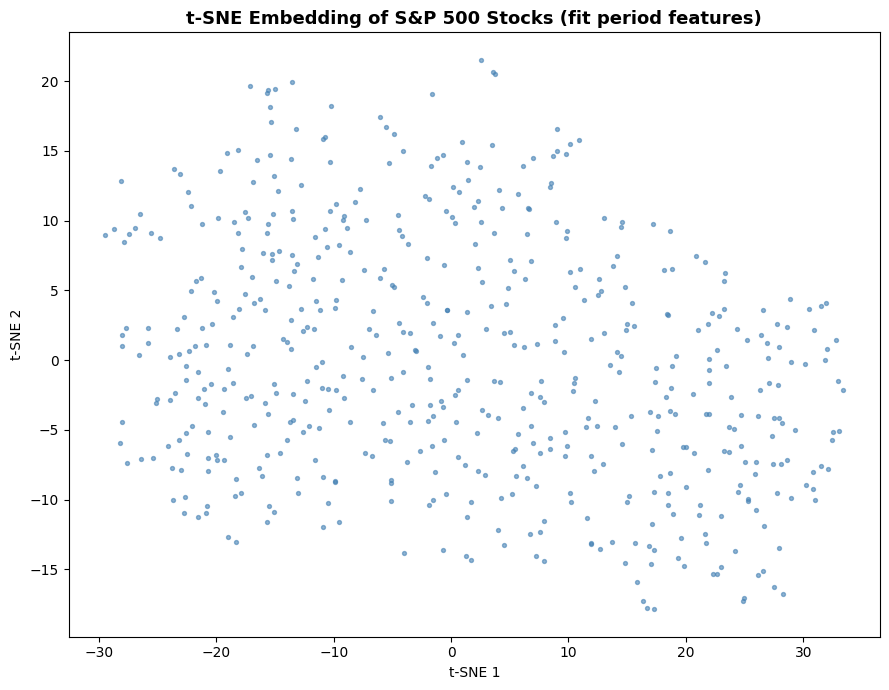

In [ ]:
print('Running t-SNE (13D → 2D)...')
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_SEED,
    n_iter=1000,
)
embedding = tsne.fit_transform(feat_scaled.values)  # (n_stocks, 2)
embed_df  = pd.DataFrame(embedding, index=feat_scaled.index, columns=['tsne_1', 'tsne_2'])

print('t-SNE embedding shape:', embed_df.shape)

# Visualize t-SNE embedding
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(embed_df['tsne_1'], embed_df['tsne_2'], s=8, alpha=0.6, color='steelblue')
ax.set_title('t-SNE Embedding of S&P 500 Stocks (fit period features)', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

## Step 3a — Affinity Propagation Clustering

Affinity Propagation automatically determines the number of clusters (no k to specify).
One representative stock (nearest to cluster centroid) is selected per cluster.

Running Affinity Propagation...
Affinity Propagation found 21 clusters
Selected 21 stocks (one per cluster):
['APH', 'ANF', 'CI', 'CFG', 'DIS', 'EW', 'HAL', 'IDXX', 'JEF', 'JBL', 'KMB', 'KEYS', 'NI', 'OI', 'NOW', 'QRVO', 'RSG', 'SNA', 'SYY', 'STLD', 'WTW']


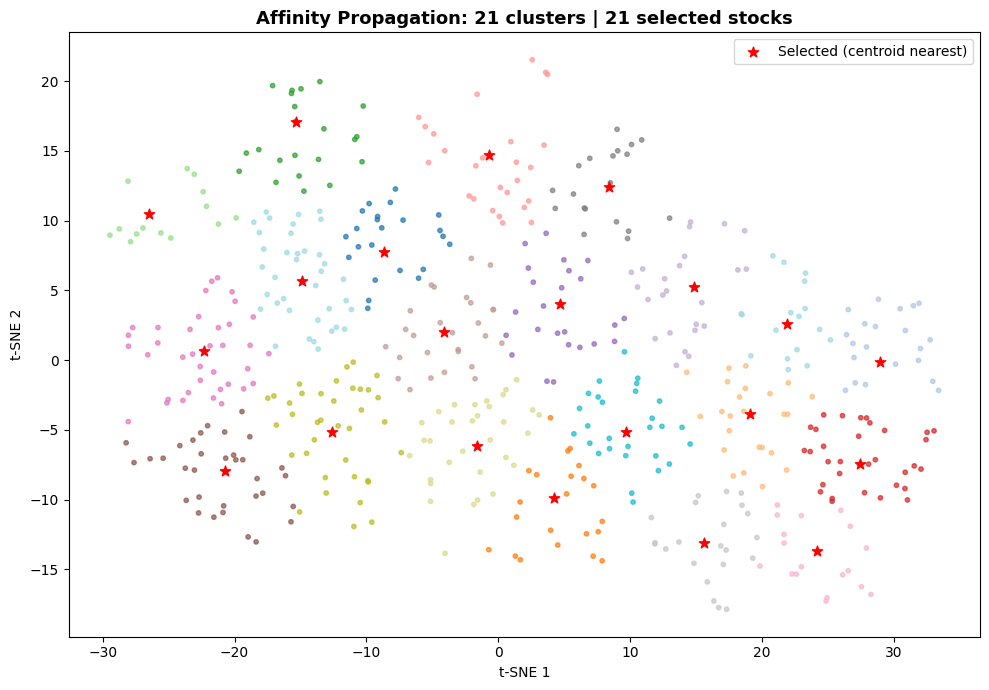

In [ ]:
def select_from_clusters(embed_df: pd.DataFrame, labels: np.ndarray) -> list:
    """For each cluster, pick the stock nearest to the cluster centroid in t-SNE space."""
    selected = []
    for cluster_id in np.unique(labels):
        if cluster_id == -1:   # noise label from some algorithms
            continue
        mask      = labels == cluster_id
        members   = embed_df.loc[mask]
        centroid  = members.values.mean(axis=0)
        dists     = np.linalg.norm(members.values - centroid, axis=1)
        nearest   = members.index[dists.argmin()]
        selected.append(nearest)
    return selected


print('Running Affinity Propagation...')
ap = AffinityPropagation(
    damping=0.85,
    max_iter=300,
    convergence_iter=20,
    random_state=RANDOM_SEED,
)
ap.fit(embed_df.values)
ap_labels = ap.labels_
n_clusters_ap = len(np.unique(ap_labels))
print(f'Affinity Propagation found {n_clusters_ap} clusters')

ap_subset = select_from_clusters(embed_df, ap_labels)
print(f'Selected {len(ap_subset)} stocks (one per cluster):')
print(ap_subset)

# Visualize clusters
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    embed_df['tsne_1'], embed_df['tsne_2'],
    c=ap_labels, cmap='tab20', s=10, alpha=0.7
)
# Mark selected stocks
sel_embed = embed_df.loc[ap_subset]
ax.scatter(sel_embed['tsne_1'], sel_embed['tsne_2'],
           c='red', s=60, marker='*', zorder=5, label='Selected (centroid nearest)')
ax.set_title(f'Affinity Propagation: {n_clusters_ap} clusters | {len(ap_subset)} selected stocks',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 3b — K-Means Sweep (k = 10 to 100)

Run K-Means for each k in K_LIST to produce the sparsity vs TE trade-off chart required by the assignment.

In [ ]:
def fit_simplex_weights(X_train: pd.DataFrame, y_train: pd.Series, l2=1e-6):
    idx     = X_train.index.intersection(y_train.index)
    X_train = X_train.loc[idx]; y_train = y_train.loc[idx]
    Xv, yv  = X_train.values.astype(float), y_train.values.astype(float)
    k       = Xv.shape[1]
    w       = cp.Variable(k, nonneg=True)
    prob    = cp.Problem(
        cp.Minimize(cp.sum_squares(Xv @ w - yv) + l2 * cp.sum_squares(w)),
        [cp.sum(w) == 1]
    )
    for solver in [cp.OSQP, cp.ECOS, cp.SCS]:
        try:
            prob.solve(solver=solver, verbose=False)
            if w.value is not None:
                break
        except Exception:
            continue
    if w.value is None:
        return pd.Series(np.ones(k) / k, index=X_train.columns)
    ww = np.clip(w.value, 0, None)
    ww = ww / ww.sum()
    return pd.Series(ww, index=X_train.columns)


def compute_metrics(X, y, weights):
    idx    = X.index.intersection(y.index)
    cols   = X.columns.intersection(weights.index)
    rp     = X.loc[idx, cols].mul(weights[cols], axis=1).sum(axis=1)
    active = rp - y.loc[idx]
    te     = active.std(ddof=1) * np.sqrt(252)
    ir     = (active.mean() / (active.std(ddof=1) + 1e-12)) * np.sqrt(252)
    return te, ir


def evaluate_subset(subset, X_fit, y_fit, X_sel, y_sel, X_hold, y_hold):
    X_train = pd.concat([X_fit[subset], X_sel[subset]])
    y_train = pd.concat([y_fit, y_sel])
    w       = fit_simplex_weights(X_train, y_train)
    fit_te,  fit_ir  = compute_metrics(X_fit,  y_fit,  w)
    sel_te,  sel_ir  = compute_metrics(X_sel,  y_sel,  w)
    hold_te, hold_ir = compute_metrics(X_hold, y_hold, w)
    return dict(weights=w, fit_te=fit_te, sel_te=sel_te, hold_te=hold_te,
                fit_ir=fit_ir, sel_ir=sel_ir, hold_ir=hold_ir)


print('Weight optimization and evaluation functions defined.')

Weight optimization and evaluation functions defined.


In [ ]:
# K-Means sweep: k = 10 to 100
all_rows     = []
weight_store = {}

for k in tqdm(K_LIST, desc='K-Means sweep'):
    km     = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(embed_df.values)
    subset = select_from_clusters(embed_df, labels)

    # Ensure we have exactly k stocks (KMeans always gives k clusters)
    if len(subset) < k:
        # Fill up with closest remaining stocks if any cluster collapsed
        remaining = [t for t in eligible_tickers if t not in subset]
        subset    = subset + remaining[:k - len(subset)]

    metrics = evaluate_subset(subset, X_fit, y_fit, X_sel, y_sel, X_hold, y_hold)
    all_rows.append(dict(
        k=k, method='kmeans', n_selected=len(subset),
        fit_te_ann=metrics['fit_te'],   sel_te_ann=metrics['sel_te'],   hold_te_ann=metrics['hold_te'],
        fit_ir_ann=metrics['fit_ir'],   sel_ir_ann=metrics['sel_ir'],   hold_ir_ann=metrics['hold_ir'],
    ))
    weight_store[('kmeans', k)] = metrics['weights']

results = pd.DataFrame(all_rows).sort_values('k').reset_index(drop=True)
print('K-Means sweep done. Results shape:', results.shape)
results.head()

K-Means sweep:   0%|          | 0/91 [00:00<?, ?it/s]

K-Means sweep done. Results shape: (91, 9)


,k,method,n_selected,fit_te_ann,sel_te_ann,hold_te_ann,fit_ir_ann,sel_ir_ann,hold_ir_ann
0,10,kmeans,10,0.084127,0.117985,0.108078,0.569647,-0.454732,0.765926
1,11,kmeans,11,0.094102,0.144218,0.135144,0.099277,-0.675860,0.067769
2,12,kmeans,12,0.106515,0.124136,0.131338,0.089059,-1.236850,-1.456944
3,13,kmeans,13,0.072040,0.090168,0.096761,0.682835,0.535924,0.446249
4,14,kmeans,14,0.065586,0.112902,0.120674,0.316308,-0.325619,-1.414197


In [ ]:
# Evaluate Affinity Propagation portfolio
ap_metrics   = evaluate_subset(ap_subset, X_fit, y_fit, X_sel, y_sel, X_hold, y_hold)
ap_weights   = ap_metrics['weights']

print(f'\n=== Affinity Propagation ({len(ap_subset)} stocks) ===')
print(f'  Fit TE:  {ap_metrics["fit_te"]:.4f}  |  Fit IR:  {ap_metrics["fit_ir"]:.4f}')
print(f'  Sel TE:  {ap_metrics["sel_te"]:.4f}  |  Sel IR:  {ap_metrics["sel_ir"]:.4f}')
print(f'  Hold TE: {ap_metrics["hold_te"]:.4f}  |  Hold IR: {ap_metrics["hold_ir"]:.4f}')

ap_selection = pd.DataFrame({'ticker': ap_weights.index, 'weight': ap_weights.values})\
                 .sort_values('weight', ascending=False)
display(ap_selection.head(20))


=== Affinity Propagation (21 stocks) ===
  Fit TE:  0.0649  |  Fit IR:  0.5106
  Sel TE:  0.0745  |  Sel IR:  1.8530
  Hold TE: 0.0808  |  Hold IR: -1.1931


,ticker,weight
0,APH,0.134116
10,KMB,0.111665
16,RSG,0.101236
14,NOW,0.092412
7,IDXX,0.065063
4,DIS,0.061431
12,NI,0.057472
11,KEYS,0.052847
2,CI,0.046412
15,QRVO,0.045380


In [ ]:
# Best K-Means results per k<=50
sub      = results[results['k'] <= 50].copy()
best_row = sub.loc[sub['hold_te_ann'].idxmin()]
best_k   = int(best_row['k'])
best_weights = weight_store[('kmeans', best_k)]

print(f'Best K-Means k by holdout TE: {best_k}')
print(best_row.to_string())

best_selection = pd.DataFrame({'ticker': best_weights.index, 'weight': best_weights.values})\
                   .sort_values('weight', ascending=False)
display(best_selection.head(20))

Best K-Means k by holdout TE: 50
k                    50
method           kmeans
n_selected           50
fit_te_ann     0.045621
sel_te_ann     0.054159
hold_te_ann    0.064329
fit_ir_ann     1.647374
sel_ir_ann    -0.182302
hold_ir_ann    1.915358


,ticker,weight
49,GOOGL,0.125924
39,ATO,0.070150
9,NVDA,0.067395
2,TXN,0.060581
23,MO,0.055154
37,EA,0.048966
5,BDX,0.043937
12,HON,0.043335
10,C,0.043228
20,PSA,0.040114


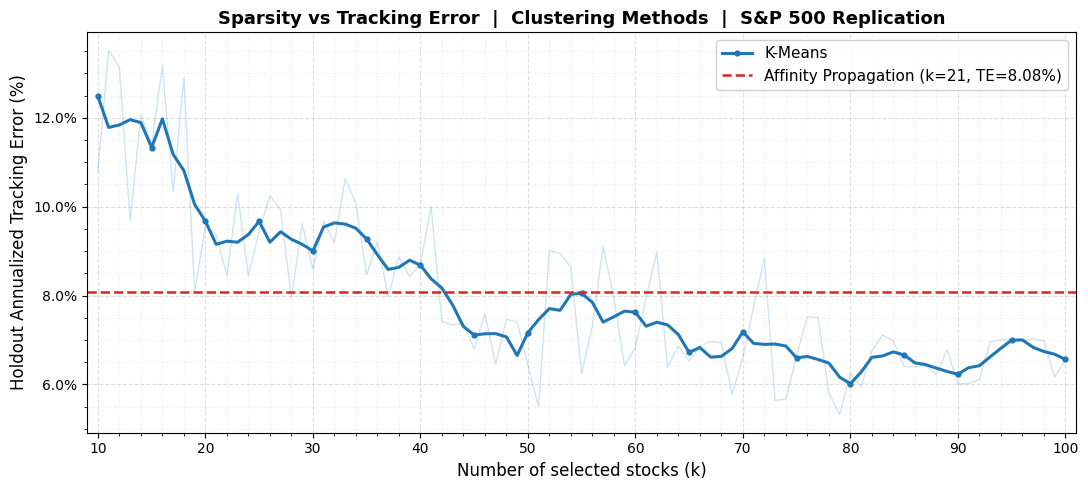

In [ ]:
# Sparsity vs Tracking Error plot
WINDOW = 5
fig, ax = plt.subplots(figsize=(11, 5))

raw      = results['hold_te_ann'].values
k_vals   = results['k'].values
smoothed = pd.Series(raw).rolling(WINDOW, center=True, min_periods=1).mean().values

ax.plot(k_vals, raw * 100,      color='#1f77b4', alpha=0.20, linewidth=1)
ax.plot(k_vals, smoothed * 100, color='#1f77b4', linewidth=2.2,
        label='K-Means', marker='o', markersize=3.5, markevery=5)

# Affinity Propagation as a single point
ax.axhline(
    ap_metrics['hold_te'] * 100,
    color='#d62728', linestyle='--', linewidth=1.8,
    label=f'Affinity Propagation (k={len(ap_subset)}, TE={ap_metrics["hold_te"]*100:.2f}%)'
)

ax.set_xlabel('Number of selected stocks (k)', fontsize=12)
ax.set_ylabel('Holdout Annualized Tracking Error (%)', fontsize=12)
ax.set_title('Sparsity vs Tracking Error  |  Clustering Methods  |  S&P 500 Replication',
             fontsize=13, fontweight='bold')
ax.set_xlim(9, 101)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()
plt.tight_layout()
plt.show()

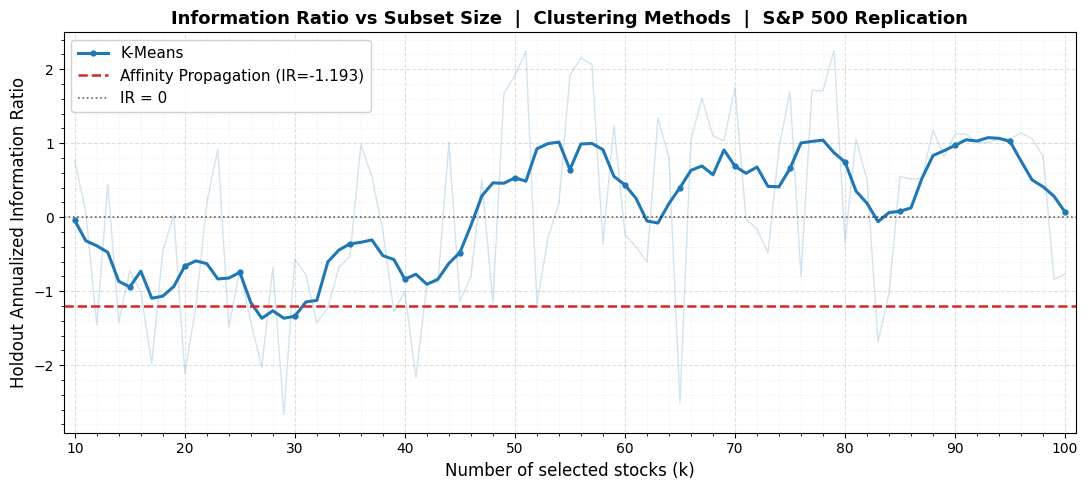

In [ ]:
# Information Ratio vs k plot
WINDOW = 7
fig, ax = plt.subplots(figsize=(11, 5))

raw      = results['hold_ir_ann'].values
smoothed = pd.Series(raw).rolling(WINDOW, center=True, min_periods=1).mean().values

ax.plot(k_vals, raw,      color='#1f77b4', alpha=0.20, linewidth=1)
ax.plot(k_vals, smoothed, color='#1f77b4', linewidth=2.2,
        label='K-Means', marker='o', markersize=3.5, markevery=5)
ax.axhline(
    ap_metrics['hold_ir'],
    color='#d62728', linestyle='--', linewidth=1.8,
    label=f'Affinity Propagation (IR={ap_metrics["hold_ir"]:.3f})'
)
ax.axhline(0, color='black', linewidth=1.2, linestyle=':', alpha=0.6, label='IR = 0')

ax.set_xlabel('Number of selected stocks (k)', fontsize=12)
ax.set_ylabel('Holdout Annualized Information Ratio', fontsize=12)
ax.set_title('Information Ratio vs Subset Size  |  Clustering Methods  |  S&P 500 Replication',
             fontsize=13, fontweight='bold')
ax.set_xlim(9, 101)
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()
plt.tight_layout()
plt.show()

Loaded sector map from cache (unknown rate: 0.9%)
Loaded market caps from cache
Sector weight mode: market-cap weighted


,market_cap
sector,
Technology,0.302430
Communication Services,0.164532
Financial Services,0.121099
Consumer Cyclical,0.096971
Healthcare,0.087617
Industrials,0.073892
Consumer Defensive,0.056540
Energy,0.036462
Utilities,0.021816


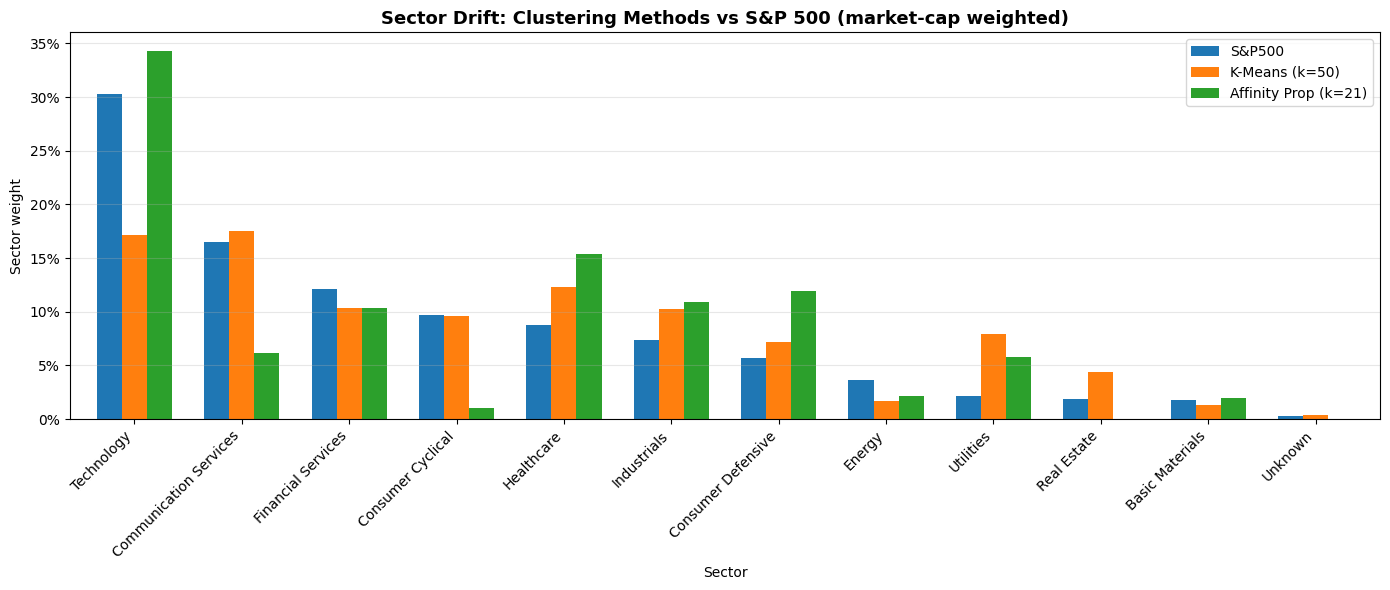

,S&P500,K-Means (k=50),Affinity Prop (k=21)
sector,,,
Technology,0.3024,0.1712,0.3432
Communication Services,0.1645,0.1749,0.0614
Financial Services,0.1211,0.1031,0.1037
Consumer Cyclical,0.0970,0.0957,0.0106
Healthcare,0.0876,0.1235,0.1540
Industrials,0.0739,0.1029,0.1092
Consumer Defensive,0.0565,0.0719,0.1194
Energy,0.0365,0.0167,0.0212
Utilities,0.0218,0.0796,0.0575


In [ ]:
# Sector drift plot

def get_sp500_sector_map(tickers, cache_path: Path, max_workers: int = 16):
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        if set(tickers).issubset(set(cached['ticker'])):
            unknown_rate = (cached['sector'] == 'Unknown').mean()
            if unknown_rate < 0.10:
                print(f'Loaded sector map from cache (unknown rate: {unknown_rate:.1%})')
                return cached
            print(f'Cache stale ({unknown_rate:.1%} unknown), refetching...')

    sector_map = {}
    try:
        tables  = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
        wiki    = tables[0]
        sym_col = [c for c in wiki.columns if 'symbol' in c.lower() or 'ticker' in c.lower()][0]
        sec_col = [c for c in wiki.columns if 'gics sector' in c.lower() or 'sector' in c.lower()][0]
        for _, row in wiki.iterrows():
            sym = str(row[sym_col]).strip().replace('.', '-')
            sector_map[sym] = str(row[sec_col]).strip()
        print(f'Wikipedia: mapped {len(sector_map)} tickers')
    except Exception as e:
        print(f'Wikipedia failed: {e}')

    still_unknown = [t for t in tickers if sector_map.get(t, 'Unknown') == 'Unknown']
    if still_unknown:
        def fetch_yf(t):
            try:
                return t, yf.Ticker(t).get_info().get('sector') or 'Unknown'
            except Exception:
                return t, 'Unknown'
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futs = {ex.submit(fetch_yf, t): t for t in still_unknown}
            for fut in tqdm(as_completed(futs), total=len(futs), desc='yfinance fallback'):
                t, s = fut.result(); sector_map[t] = s

    df = pd.DataFrame([{'ticker': t, 'sector': sector_map.get(t, 'Unknown')} for t in tickers])
    print(f'Final unknown rate: {(df["sector"]=="Unknown").mean():.1%}')
    try:
        df.to_csv(cache_path, index=False)
    except Exception as e:
        print('Warning: could not save cache:', e)
    return df


def get_market_caps(tickers, cache_path: Path, max_workers: int = 16):
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        if set(tickers).issubset(set(cached['ticker'])):
            if cached['market_cap'].notna().mean() >= 0.5:
                print('Loaded market caps from cache')
                return cached
    def fetch_one(t):
        try:
            fi = getattr(yf.Ticker(t), 'fast_info', None)
            mc = getattr(fi, 'market_cap', np.nan) if fi is not None else np.nan
            if pd.isna(mc):
                mc = yf.Ticker(t).get_info().get('marketCap', np.nan)
        except Exception:
            mc = np.nan
        return {'ticker': t, 'market_cap': mc}
    rows = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(fetch_one, t): t for t in tickers}
        for fut in tqdm(as_completed(futs), total=len(futs), desc='Fetching market caps'):
            rows.append(fut.result())
    out = pd.DataFrame(rows)
    try:
        out.to_csv(cache_path, index=False)
    except Exception as e:
        print('Warning: could not save cache:', e)
    return out


sector_df     = get_sp500_sector_map(eligible_tickers, SECTOR_CACHE)
universe_info = sector_df.copy()

try:
    mcap = get_market_caps(universe_info['ticker'].tolist(), MARKETCAP_CACHE)
    universe_info = universe_info.merge(mcap, on='ticker', how='left')
    valid = universe_info['market_cap'].notna().sum()
    if valid >= max(30, int(0.3 * len(universe_info))):
        universe_info['market_cap'] = universe_info.groupby('sector')['market_cap'].transform(
            lambda s: s.fillna(s.median())
        ).fillna(universe_info['market_cap'].median())
        sector_weights_true = universe_info.groupby('sector')['market_cap'].sum()
        sector_weights_true = sector_weights_true / sector_weights_true.sum()
        sector_weight_mode  = 'market-cap weighted'
    else:
        raise ValueError('Too many missing market caps')
except Exception as e:
    print('Market cap failed, using equal-weight proxy:', e)
    sector_weights_true = universe_info['sector'].value_counts(normalize=True)
    sector_weight_mode  = 'equal-weight proxy'

print('Sector weight mode:', sector_weight_mode)
display(sector_weights_true.sort_values(ascending=False).head(10))


def sector_weights_for_portfolio(weights, universe_info):
    df  = pd.DataFrame({'ticker': weights.index, 'weight': weights.values})
    df  = df.merge(universe_info[['ticker', 'sector']], on='ticker', how='left')
    df['sector'] = df['sector'].fillna('Unknown')
    return df.groupby('sector')['weight'].sum()


sw_ap = sector_weights_for_portfolio(ap_weights,   universe_info)
sw_km = sector_weights_for_portfolio(best_weights, universe_info)

sector_compare = pd.DataFrame({
    'S&P500':                            sector_weights_true,
    f'K-Means (k={best_k})':             sw_km,
    f'Affinity Prop (k={len(ap_subset)})': sw_ap,
}).fillna(0.0).sort_values('S&P500', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sector_compare.plot(kind='bar', ax=ax, width=0.7)
ax.set_ylabel('Sector weight')
ax.set_xlabel('Sector')
ax.set_title(f'Sector Drift: Clustering Methods vs S&P 500 ({sector_weight_mode})',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

sector_compare.round(4)